<div align="center">
  <img src="LOGO-UPATECO-MEJORADO.png" width="250">
  
  # PROYECTO INTEGRADOR
  ### MODULO: CIENCIA DE DATOS Y OPTIMIZACION DE MODELOS
  **CARRERA: TECNICATURA UNIVERSITARIA EN CIENCIA DE DATOS E IA APLICADA**
  
  ---
  
  ## Titulo: Analisis Predictivo y Optimizacion de Modelos en Spotify
  
  **EQUIPO N 1**
  
  **Integrantes:**
  1. Alvarado, Marcelo Daniel - DNI: 39.781.697
  2. Biazutti, Jorge Luciano - DNI: 23.584.366
  3. Casasola, Hernan Guido Gustavo - DNI: 29.976.458
  4. Gonza, Gabriela Guadalupe - DNI: 31.173.807
  5. Lera, Anibal Ivan - DNI: 18.229.630
  
  **Docente:** Amalia Guaymas Canavire
  **Fecha:** 2026
</div>

---
## Ficha Tecnica del Conjunto de Datos

| Campo | Descripcion |
| :--- | :--- |
| **Nombre del conjunto de datos** | Spotify 1 Million Tracks |
| **Institucion que lo creo** | Amitansh Joshi (recopilacion independiente) |
| **Proposito de creacion** | Proveer un conjunto de datos masivo de caracteristicas de audio de Spotify para investigacion y analisis de datos musicales |
| **Mecanismo de recoleccion** | API Web de Spotify (endpoints de audio features y tracks) |
| **Documentacion disponible** | Si, documentacion de la API de Spotify con descripcion detallada de cada variable de audio |
| **Fuente** | Kaggle - https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks |
| **Registros originales** | 1,000,000+ |
| **Muestra utilizada** | 100,000 registros (muestreo aleatorio con random_state=42) |

### Diccionario de Datos

| Variable | Descripcion | Tipo de Dato | Valores Aceptados | Acepta Nulos |
| :--- | :--- | :--- | :--- | :--- |
| artist_name | Nombre del artista o banda | Cualitativa (string) | Texto libre | Si |
| track_name | Nombre de la pista musical | Cualitativa (string) | Texto libre | Si |
| track_id | Identificador unico de Spotify | Cualitativa (string) | ID alfanumerico | No |
| popularity | Nivel de popularidad de la pista | Cuantitativa discreta (int) | 0 a 100 | No |
| year | Anio de lanzamiento | Cuantitativa discreta (int) | 1900 - 2026 | No |
| genre | Genero musical | Cualitativa (string) | Categorias predefinidas | No |
| danceability | Que tan adecuada es la pista para bailar | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| energy | Medida de intensidad y actividad | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| key | Tonalidad musical de la pista | Cuantitativa discreta (int) | 0 a 11 (escala cromatica) | No |
| loudness | Volumen promedio en decibeles | Cuantitativa continua (float) | -60 a 0 dB | No |
| mode | Modalidad (mayor o menor) | Cuantitativa discreta (int) | 0 = menor, 1 = mayor | No |
| speechiness | Presencia de palabras habladas | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| acousticness | Probabilidad de que sea acustica | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| instrumentalness | Probabilidad de que no tenga voz | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| liveness | Probabilidad de ser en vivo | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| valence | Positividad musical transmitida | Cuantitativa continua (float) | 0.0 a 1.0 | No |
| tempo | Velocidad en BPM (beats por minuto) | Cuantitativa continua (float) | 0 a 250+ | No |
| duration_ms | Duracion de la pista en milisegundos | Cuantitativa continua (int) | > 0 | No |
| time_signature | Compas musical | Cuantitativa discreta (int) | 1 a 7 | No |

---
# ENTREGA 1: ANALISIS EXPLORATORIO DE DATOS

## 1. Objetivos y Alcances

### 1.a Objetivo General
Analizar las caracteristicas de audio del catalogo musical de Spotify para identificar patrones y relaciones que permitan comprender que factores influyen en la popularidad de una pista musical. Este analisis servira como base para la construccion de modelos predictivos en la Entrega 2.

### 1.b Descripcion de Variables
El conjunto de datos contiene 20 variables que describen las propiedades musicales y metadata de cada pista. Se pueden agrupar en:
- **Variables de identificacion:** artist_name, track_name, track_id
- **Variables de contexto:** year, genre, popularity
- **Variables de audio (features de Spotify):** danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms
- **Variables musicales teoricas:** key, mode, time_signature

## 2. Analisis Exploratorio de Datos

### 2.a Carga del Conjunto de Datos

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configuracion de visualizacion
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# Rutas de acceso
data_filename = 'spotify_mini_100k.csv'
data_local_path = f'data/{data_filename}'
github_url = "https://raw.githubusercontent.com/GuidoMaxier/Proyecto-Integrador-Equipo1/main/data/spotify_mini_100k.csv"

def get_dataset():
    if os.path.exists(data_local_path):
        print(f"Cargando dataset desde: {data_local_path}")
        return pd.read_csv(data_local_path)
    elif github_url != "":
        print("Descargando dataset desde GitHub...")
        return pd.read_csv(github_url)
    return None

df = get_dataset()

# Eliminamos la columna indice innecesaria si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset cargado: {df.shape[0]} registros y {df.shape[1]} columnas.")
display(df.head())

Cargando dataset desde: data/spotify_mini_100k.csv
Dataset cargado: 100000 registros y 19 columnas.


,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Alexandre Desplat,Memorial,1pJdDgOdRUEizV3s3TfJXX,16,2012,french,0.1870,0.102,8,-23.448,0,0.0394,0.76700,0.979000,0.2810,0.0418,64.790,83813,4
1,Sunmoon,Wonder,6pWZtdHl6zVDMRfAjIv2RB,40,2022,french,0.6900,0.626,1,-9.116,1,0.0354,0.80100,0.000261,0.0928,0.3390,114.925,145119,3
2,Cradle Of Filth,The Black Goddess Rises II - Ebon Nemesis,4P0OtXWT10zbI2RhEhzEbz,20,2001,black-metal,0.1950,0.880,2,-7.119,1,0.1470,0.00404,0.086300,0.1130,0.2590,200.025,442093,4
3,Venetian Snares,Welfare Wednesday,3QH6kXXor5xDmW1atcCcco,9,2010,techno,0.5530,0.951,10,-1.145,0,0.0517,0.01290,0.016200,0.3160,0.2470,173.963,243347,1
4,Crib,Constant,5gn3NZfn8eoCdNxFMbMtlz,0,2000,ambient,0.0608,0.115,2,-25.985,1,0.0519,0.20300,0.841000,0.1120,0.0312,67.494,619227,4


### 2.b Identificacion de Variables
Clasificamos las variables en cuantitativas y cualitativas, e identificamos las mas relevantes para nuestro objetivo.

In [17]:
# Clasificacion automatica de variables
cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()
cualitativas = df.select_dtypes(include=['object']).columns.tolist()

print("VARIABLES CUANTITATIVAS:")
for v in cuantitativas:
    print(f"  - {v}")

print(f"\nVARIABLES CUALITATIVAS:")
for v in cualitativas:
    print(f"  - {v}")

print(f"\nTotal cuantitativas: {len(cuantitativas)}")
print(f"Total cualitativas: {len(cualitativas)}")

VARIABLES CUANTITATIVAS:
  - popularity
  - year
  - danceability
  - energy
  - key
  - loudness
  - mode
  - speechiness
  - acousticness
  - instrumentalness
  - liveness
  - valence
  - tempo
  - duration_ms
  - time_signature

VARIABLES CUALITATIVAS:
  - artist_name
  - track_name
  - track_id
  - genre

Total cuantitativas: 15
Total cualitativas: 4


### 2.c Resumen Descriptivo (Analisis Univariado)
Calculamos medidas de tendencia central (media, mediana) y de dispersion (desviacion estandar, rango intercuartilico).

In [18]:
print("Resumen estadistico de variables numericas:")
display(df.describe().T)

Resumen estadistico de variables numericas:


,count,mean,std,min,25%,50%,75%,max
popularity,100000.0,18.424470,15.893789,0.000,5.000000,15.00000,29.0000,94.000
year,100000.0,2011.983950,6.805415,2000.000,2006.000000,2012.00000,2018.0000,2023.000
danceability,100000.0,0.538313,0.185298,0.000,0.413000,0.55000,0.6790,0.986
energy,100000.0,0.638366,0.270125,0.000,0.452000,0.69100,0.8720,1.000
key,100000.0,5.302210,3.562222,0.000,2.000000,5.00000,8.0000,11.000
loudness,100000.0,-8.988153,5.662964,-51.744,-10.826000,-7.45900,-5.2920,4.534
mode,100000.0,0.635580,0.481270,0.000,0.000000,1.00000,1.0000,1.000
speechiness,100000.0,0.093195,0.126967,0.000,0.037100,0.05080,0.0898,0.969
acousticness,100000.0,0.322653,0.354846,0.000,0.006620,0.15000,0.6430,0.996
instrumentalness,100000.0,0.252490,0.365336,0.000,0.000001,0.00172,0.6120,1.000


### 2.d Identificacion de Problemas en los Datos

In [19]:
# Analisis de valores faltantes
print("--- Valores Faltantes por Variable ---")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
display(missing_df[missing_df['Faltantes'] > 0] if missing_df['Faltantes'].sum() > 0 else print("No se encontraron valores faltantes."))

# Analisis de duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados encontrados: {duplicados}")

--- Valores Faltantes por Variable ---
No se encontraron valores faltantes.


None


Registros duplicados encontrados: 0


### 2.e Preguntas de Interes

A partir de la exploracion inicial del dataset, se plantean las siguientes preguntas de investigacion:

1. **Existe una correlacion significativa entre la energia (energy) de una cancion y su nivel de popularidad (popularity)?** Se busca determinar si las canciones mas energeticas tienden a ser mas populares.

2. **Como ha evolucionado la danzabilidad (danceability) promedio de las canciones a lo largo de los anios?** Se pretende identificar tendencias temporales en las preferencias musicales.

3. **Que generos musicales presentan mayor variabilidad en sus niveles de popularidad y cuales son mas consistentes?** Se busca comprender la distribucion de la popularidad por genero para su posterior uso en modelos de clasificacion.

## 3. Visualizacion de Datos

### 3.a Graficos Descriptivos

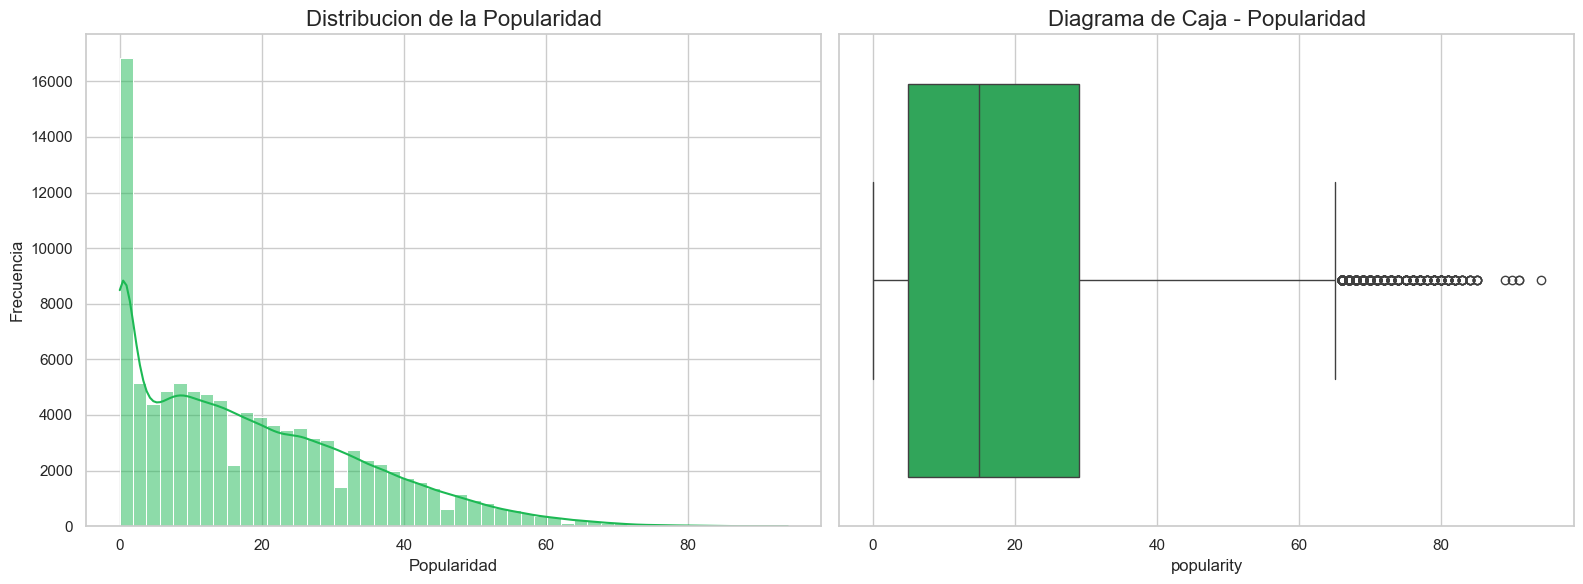

Interpretacion: La distribucion de popularidad presenta un sesgo hacia valores bajos,
lo que indica que la mayoria de las pistas tienen baja popularidad, mientras que
un numero reducido alcanza niveles altos. Esto es esperable en la industria musical.


In [20]:
# Grafico 1: Distribucion de la Popularidad (Histograma + KDE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['popularity'], kde=True, ax=axes[0], color='#1DB954', bins=50)
axes[0].set_title('Distribucion de la Popularidad')
axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=df['popularity'], ax=axes[1], color='#1DB954')
axes[1].set_title('Diagrama de Caja - Popularidad')

plt.tight_layout()
plt.show()

print("Interpretacion: La distribucion de popularidad presenta un sesgo hacia valores bajos,")
print("lo que indica que la mayoria de las pistas tienen baja popularidad, mientras que")
print("un numero reducido alcanza niveles altos. Esto es esperable en la industria musical.")

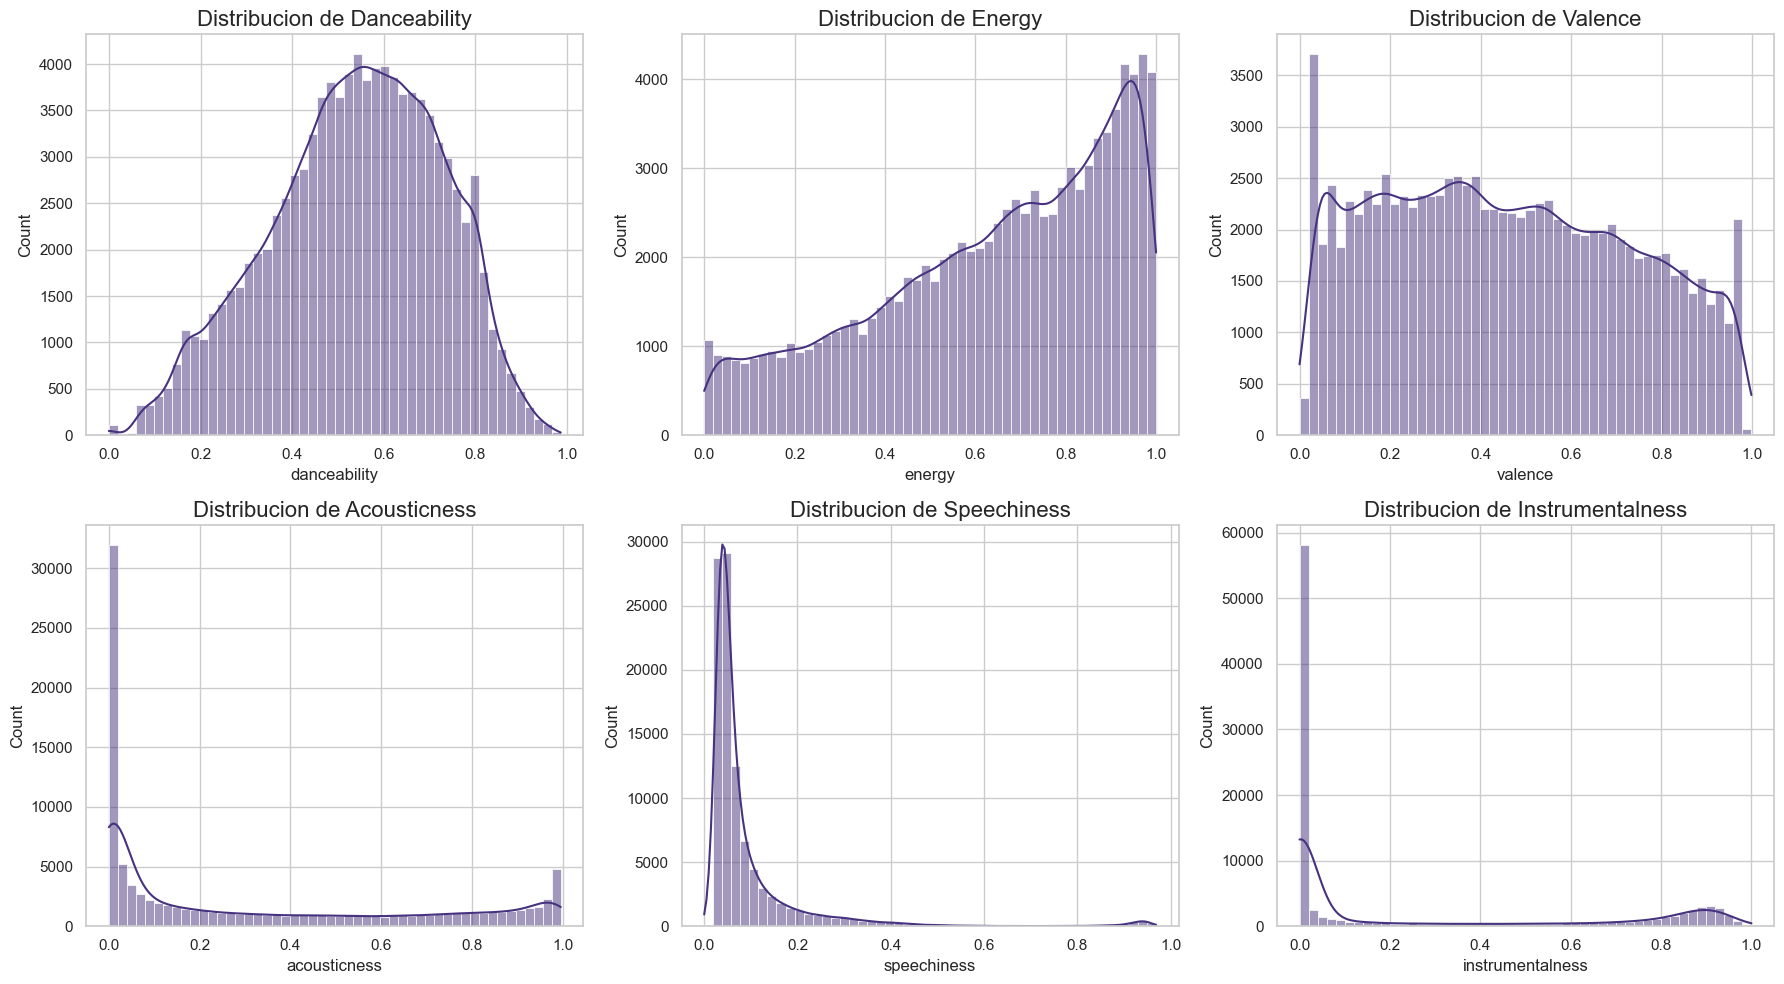

Interpretacion: Se observa que danceability y valence tienen distribuciones relativamente
uniformes, mientras que speechiness e instrumentalness concentran sus valores cerca de 0,
indicando que la mayoria de las pistas tienen poca presencia de voz hablada e instrumentacion pura.


In [21]:
# Grafico 2: Distribucion de las principales caracteristicas de audio
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'instrumentalness']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    sns.histplot(df[feature], kde=True, ax=axes[i], bins=50)
    axes[i].set_title(f'Distribucion de {feature.capitalize()}')
    axes[i].set_xlabel(feature)

plt.tight_layout()
plt.show()

print("Interpretacion: Se observa que danceability y valence tienen distribuciones relativamente")
print("uniformes, mientras que speechiness e instrumentalness concentran sus valores cerca de 0,")
print("indicando que la mayoria de las pistas tienen poca presencia de voz hablada e instrumentacion pura.")

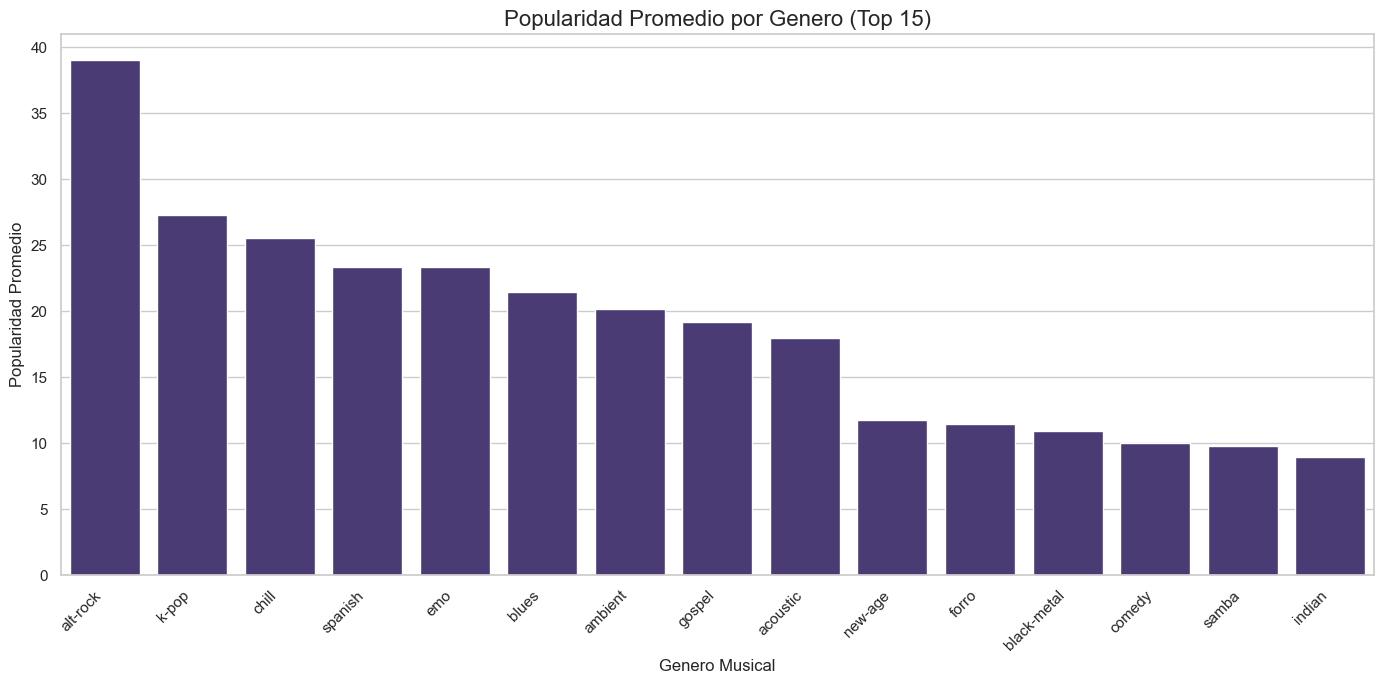

Interpretacion: Existen diferencias notables entre generos. Algunos generos como pop y
dance presentan mayor popularidad promedio, lo cual los convierte en candidatos relevantes
para la variable predictora en modelos de clasificacion (Entrega 2).


In [22]:
# Grafico 3: Popularidad promedio por genero (Top 15 generos)
top_genres = df['genre'].value_counts().head(15).index
df_top = df[df['genre'].isin(top_genres)]

plt.figure(figsize=(14, 7))
genre_order = df_top.groupby('genre')['popularity'].mean().sort_values(ascending=False).index
sns.barplot(data=df_top, x='genre', y='popularity', order=genre_order, ci=None)
plt.title('Popularidad Promedio por Genero (Top 15)')
plt.xlabel('Genero Musical')
plt.ylabel('Popularidad Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretacion: Existen diferencias notables entre generos. Algunos generos como pop y")
print("dance presentan mayor popularidad promedio, lo cual los convierte en candidatos relevantes")
print("para la variable predictora en modelos de clasificacion (Entrega 2).")

### 3.b Graficos de Correlacion y Dispersion

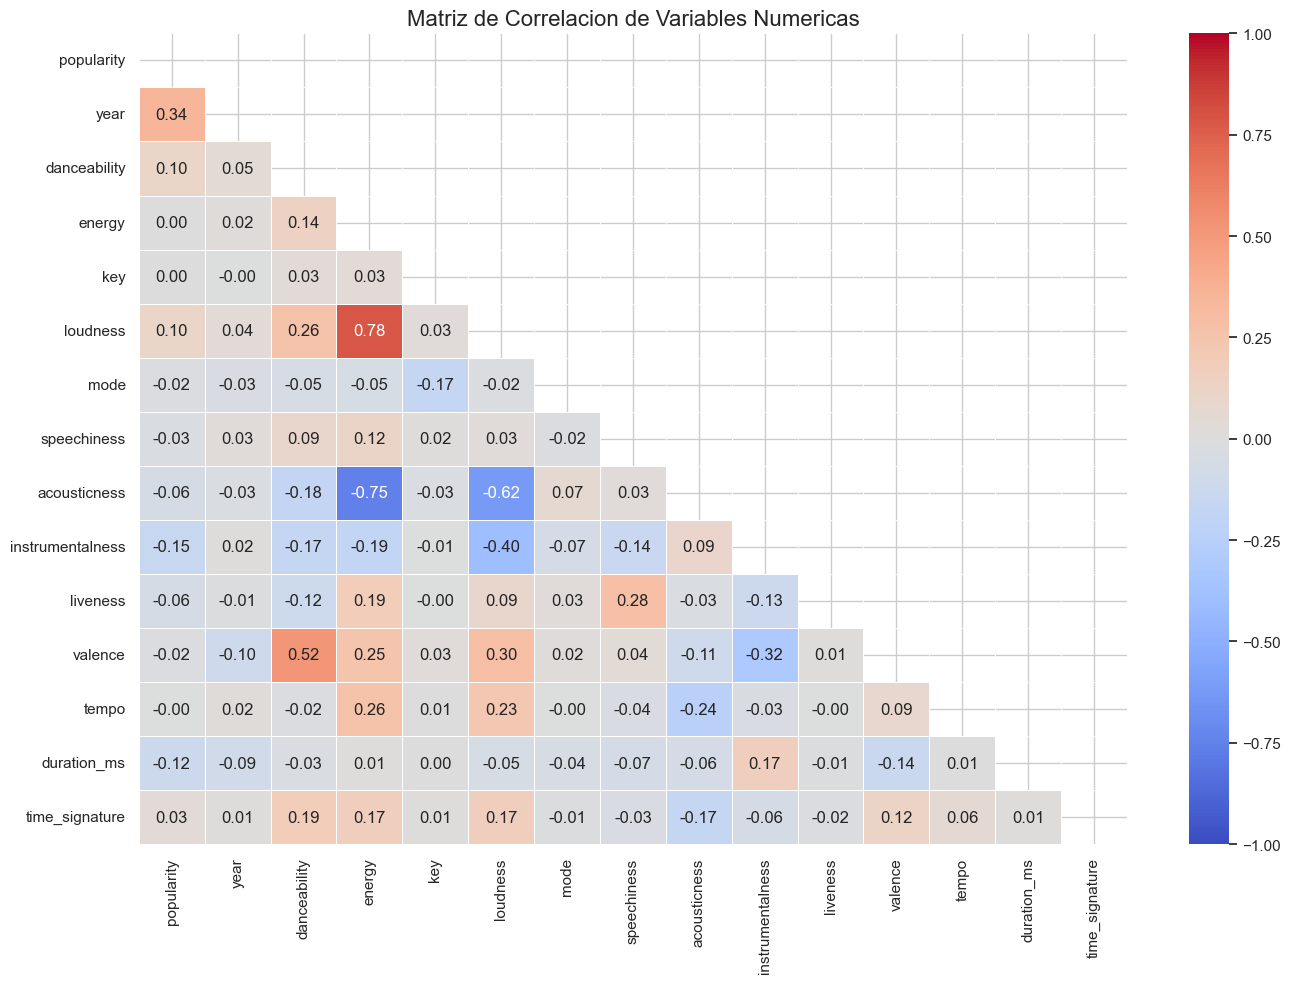

Interpretacion: Se destaca una correlacion positiva fuerte entre energy y loudness,
lo cual tiene sentido fisico (mayor energia implica mayor volumen). Tambien se observa
una correlacion negativa entre energy y acousticness (las pistas acusticas tienden a ser
menos energeticas). Estas relaciones seran clave para la seleccion de variables en la Entrega 2.


In [23]:
# Grafico 4: Matriz de Correlacion
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlacion de Variables Numericas')
plt.tight_layout()
plt.show()

print("Interpretacion: Se destaca una correlacion positiva fuerte entre energy y loudness,")
print("lo cual tiene sentido fisico (mayor energia implica mayor volumen). Tambien se observa")
print("una correlacion negativa entre energy y acousticness (las pistas acusticas tienden a ser")
print("menos energeticas). Estas relaciones seran clave para la seleccion de variables en la Entrega 2.")

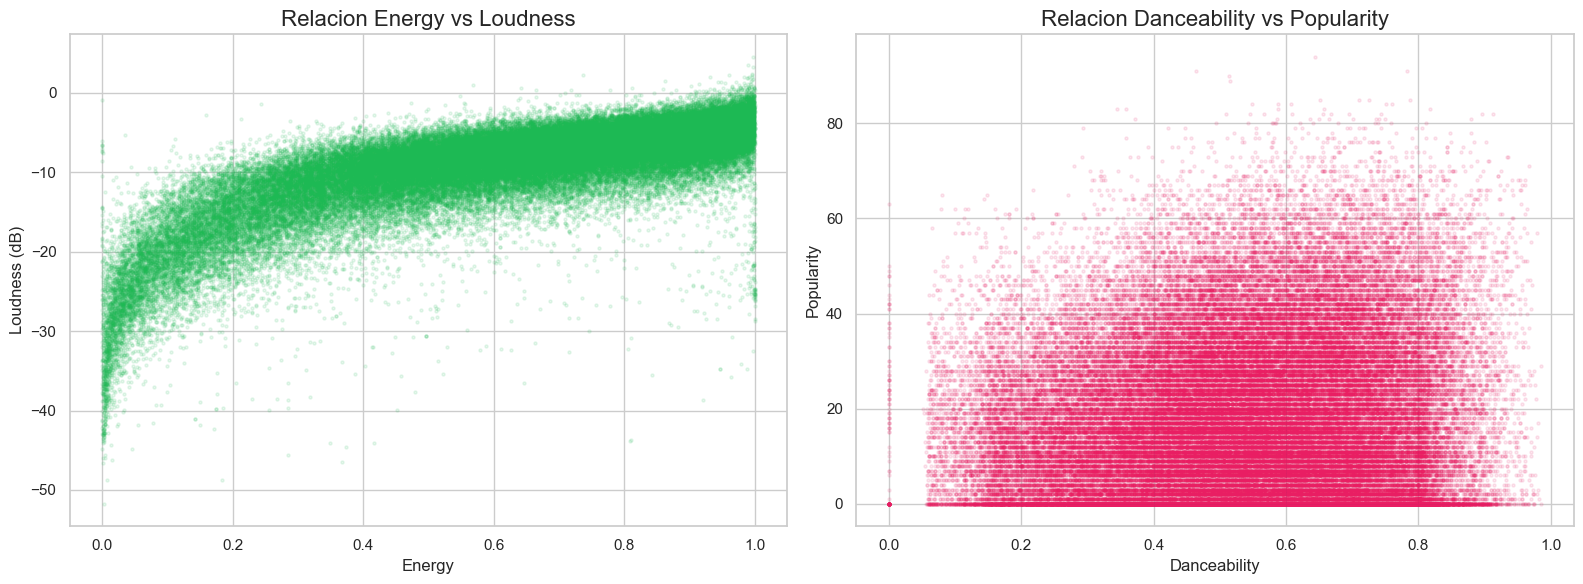

Interpretacion: La relacion entre energy y loudness muestra un patron claro y positivo.
En cambio, la relacion entre danceability y popularity no es tan directa, lo que sugiere
que la popularidad depende de multiples factores y no solo de la danzabilidad.


In [24]:
# Grafico 5: Dispersion entre Energy y Loudness (alta correlacion esperada)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['energy'], df['loudness'], alpha=0.1, s=5, color='#1DB954')
axes[0].set_title('Relacion Energy vs Loudness')
axes[0].set_xlabel('Energy')
axes[0].set_ylabel('Loudness (dB)')

axes[1].scatter(df['danceability'], df['popularity'], alpha=0.1, s=5, color='#E91E63')
axes[1].set_title('Relacion Danceability vs Popularity')
axes[1].set_xlabel('Danceability')
axes[1].set_ylabel('Popularity')

plt.tight_layout()
plt.show()

print("Interpretacion: La relacion entre energy y loudness muestra un patron claro y positivo.")
print("En cambio, la relacion entre danceability y popularity no es tan directa, lo que sugiere")
print("que la popularidad depende de multiples factores y no solo de la danzabilidad.")

## 4. Problemas con los Datos

### 4.a Evaluacion de Datos Faltantes

In [25]:
# Visualizacion de datos faltantes
print("Resumen de valores faltantes por columna:")
missing_summary = pd.DataFrame({
    'Variable': df.columns,
    'Nulos': df.isnull().sum().values,
    'Porcentaje': (df.isnull().sum().values / len(df) * 100).round(2)
})
display(missing_summary)

total_nulos = df.isnull().sum().sum()
print(f"\nTotal de valores nulos en el dataset: {total_nulos}")
if total_nulos == 0:
    print("El dataset no presenta valores faltantes. Esto se debe a que durante la etapa de")
    print("preparacion de datos se aplicaron filtros de limpieza (dropna) sobre el conjunto original.")

Resumen de valores faltantes por columna:


,Variable,Nulos,Porcentaje
0,artist_name,0,0.0
1,track_name,0,0.0
2,track_id,0,0.0
3,popularity,0,0.0
4,year,0,0.0
5,genre,0,0.0
6,danceability,0,0.0
7,energy,0,0.0
8,key,0,0.0
9,loudness,0,0.0



Total de valores nulos en el dataset: 0
El dataset no presenta valores faltantes. Esto se debe a que durante la etapa de
preparacion de datos se aplicaron filtros de limpieza (dropna) sobre el conjunto original.


### 4.b Identificacion de Valores Atipicos (Outliers)

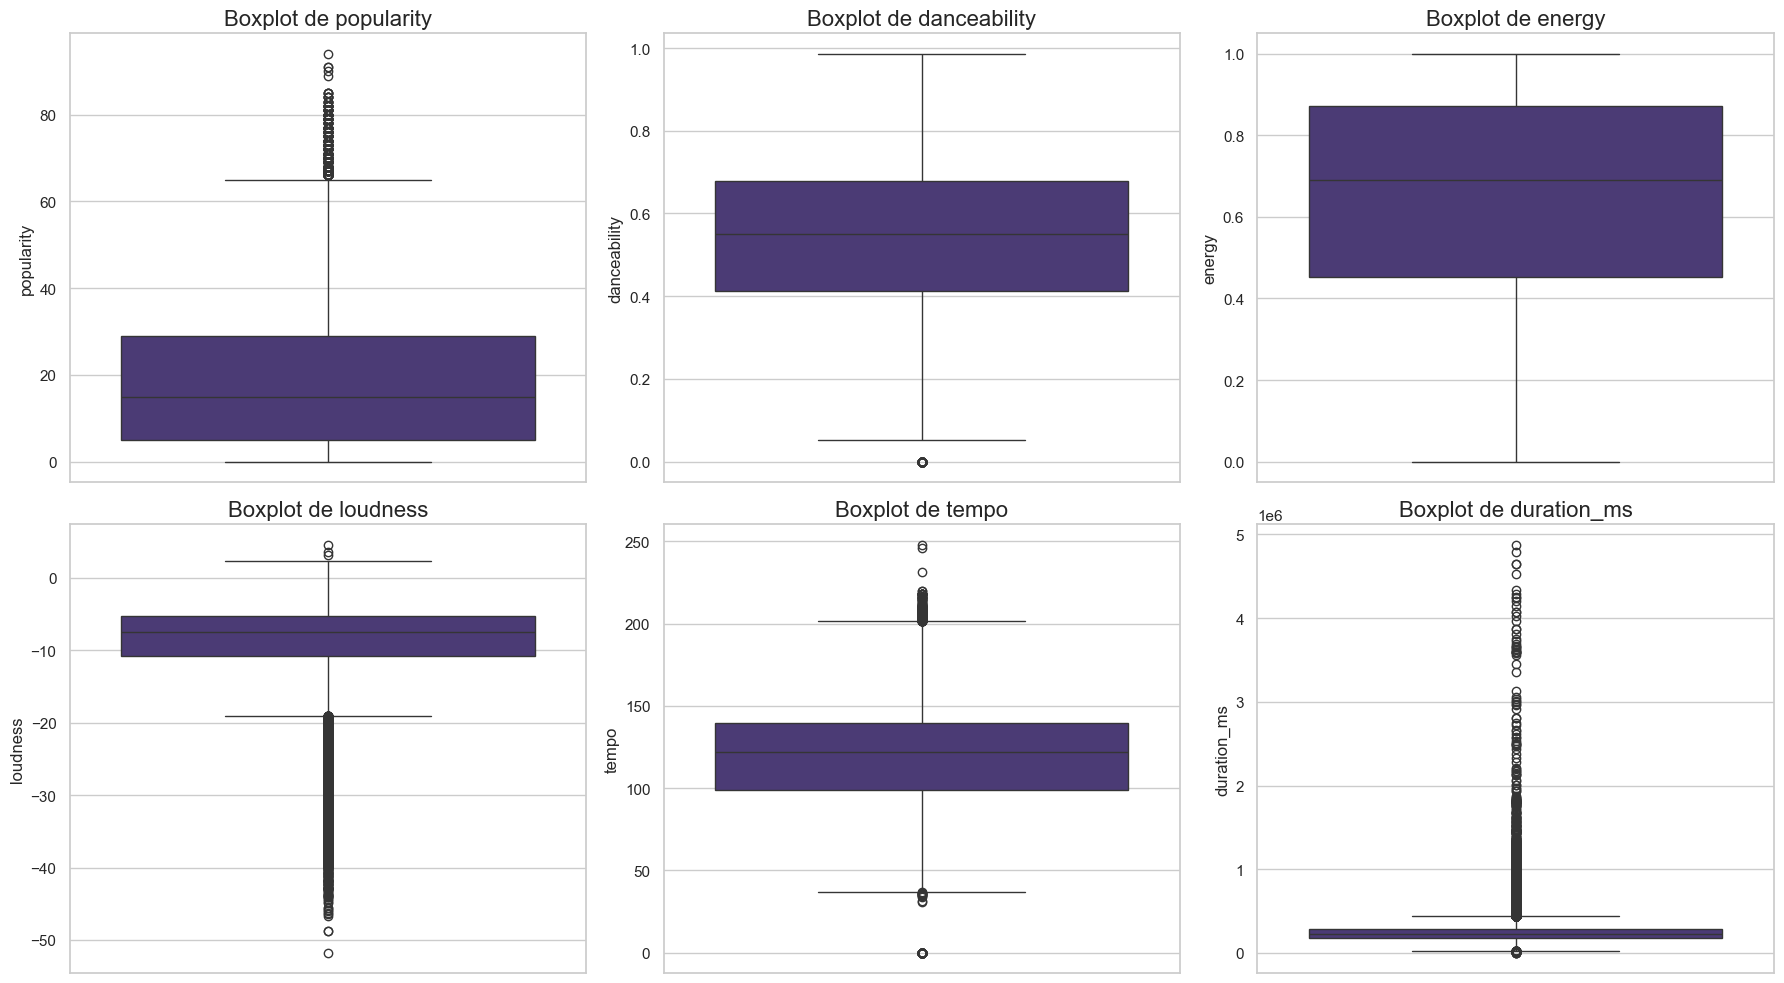


Cantidad de outliers detectados por variable (metodo IQR):
  popularity: 619 outliers (0.62%)
  danceability: 107 outliers (0.11%)
  energy: 0 outliers (0.00%)
  loudness: 6526 outliers (6.53%)
  tempo: 477 outliers (0.48%)
  duration_ms: 5231 outliers (5.23%)

Interpretacion: Las variables duration_ms y loudness presentan la mayor cantidad de
valores atipicos. En duration_ms esto se debe a pistas muy cortas (intros) o muy largas
(sets en vivo). Estos valores no se eliminan en esta etapa ya que podrian ser relevantes
para el analisis de la Entrega 2.


In [26]:
# Analisis de outliers con metodo IQR para las variables de audio principales
outlier_vars = ['popularity', 'danceability', 'energy', 'loudness', 'tempo', 'duration_ms']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(outlier_vars):
    sns.boxplot(y=df[var], ax=axes[i])
    axes[i].set_title(f'Boxplot de {var}')

plt.tight_layout()
plt.show()

# Cuantificacion de outliers con metodo IQR
print("\nCantidad de outliers detectados por variable (metodo IQR):")
for var in outlier_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[var] < lower) | (df[var] > upper)]
    print(f"  {var}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

print("\nInterpretacion: Las variables duration_ms y loudness presentan la mayor cantidad de")
print("valores atipicos. En duration_ms esto se debe a pistas muy cortas (intros) o muy largas")
print("(sets en vivo). Estos valores no se eliminan en esta etapa ya que podrian ser relevantes")
print("para el analisis de la Entrega 2.")

## 5. Conclusiones de la Entrega 1

### Hallazgos Relevantes
1. **Distribucion de la popularidad:** La gran mayoria de las pistas presentan niveles bajos de popularidad (0-20), con una distribucion sesgada hacia la izquierda. Esto refleja la naturaleza competitiva de la industria musical.

2. **Correlaciones clave identificadas:**
   - Energy y Loudness presentan una correlacion positiva fuerte, coherente con la teoria musical.
   - Acousticness y Energy tienen una correlacion negativa marcada.
   - La popularidad no muestra una correlacion lineal fuerte con ninguna variable individual, lo que sugiere que es un fenomeno multivariado.

3. **Calidad de los datos:** El dataset no presenta valores faltantes tras la limpieza inicial. Se identificaron outliers en duration_ms y loudness que seran evaluados en la siguiente entrega.

4. **Diferencias entre generos:** Existen diferencias significativas en la popularidad promedio entre generos, lo cual los convierte en una variable predictora potencial para modelos de clasificacion.

### Facilidades
- El dataset cuenta con una amplia variedad de variables numericas continuas que facilitan el analisis estadistico y la aplicacion de modelos de Machine Learning.
- La API de Spotify proporciona documentacion detallada sobre cada variable, lo que permite una interpretacion precisa de los resultados.

### Dificultades
- El tamano original del dataset (1M de registros, 175 MB) requirio un proceso de reduccion para garantizar tiempos de procesamiento razonables.
- La variable popularity no presenta correlaciones lineales fuertes con variables individuales, lo que anticipa la necesidad de modelos no lineales o ensamblados en la Entrega 2.
- Algunas variables como key y time_signature, aunque cuantitativas, representan categorias musicales y deben tratarse con cuidado en el modelado.

---
---
# ENTREGA 2: MODELADO Y OPTIMIZACION

*(Esta seccion sera desarrollada en la segunda fase del proyecto)*